<a href="https://colab.research.google.com/github/Hemant10HM/ANNDL-LAB_24mcs004/blob/main/ANN_LAB_5_CNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install keras
!pip install torch
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [2]:
# Importing basic Library :
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import make_regression
from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import trange, tqdm

#TensorFlow and Keras Libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
import torch
from torchvision import transforms
from tensorflow.keras.utils import to_categorical
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Hiding the warnings
import warnings
warnings.filterwarnings('ignore')

# Extra Libraries
import copy
import random
import time

In [3]:
# Define dataset path
dataset_path = "/content/drive/MyDrive/data/Pistachio_Image_Dataset"

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.125])
])

# Define custom dataset class
class PistachioDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        # Load images from "Kirmizi_Pistachio" folder (Class 0)
        kirmizi_folder = os.path.join(root_dir, "Kirmizi_Pistachio")
        for file in os.listdir(kirmizi_folder):
            if file.lower().endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(kirmizi_folder, file))
                self.labels.append(0)  # 0 for Kirmizi_Pistachio

        # Load images from "Siirt_Pistachio" folder (Class 1)
        siirt_folder = os.path.join(root_dir, "Siirt_Pistachio")
        for file in os.listdir(siirt_folder):
            if file.lower().endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(siirt_folder, file))
                self.labels.append(1)  # 1 for Siirt_Pistachio

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and label
        img_path = self.images[idx]
        label = self.labels[idx]

        # Open image
        image = Image.open(img_path).convert("L")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)

        return image, label

# Instantiate dataset
dataset = PistachioDataset(dataset_path, transform=transform)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Test the DataLoader
for images, labels in dataloader:
    print(f"Batch size: {images.shape}, Labels: {labels}")
    break

Batch size: torch.Size([64, 1, 256, 256]), Labels: tensor([1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
        1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
        0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1])


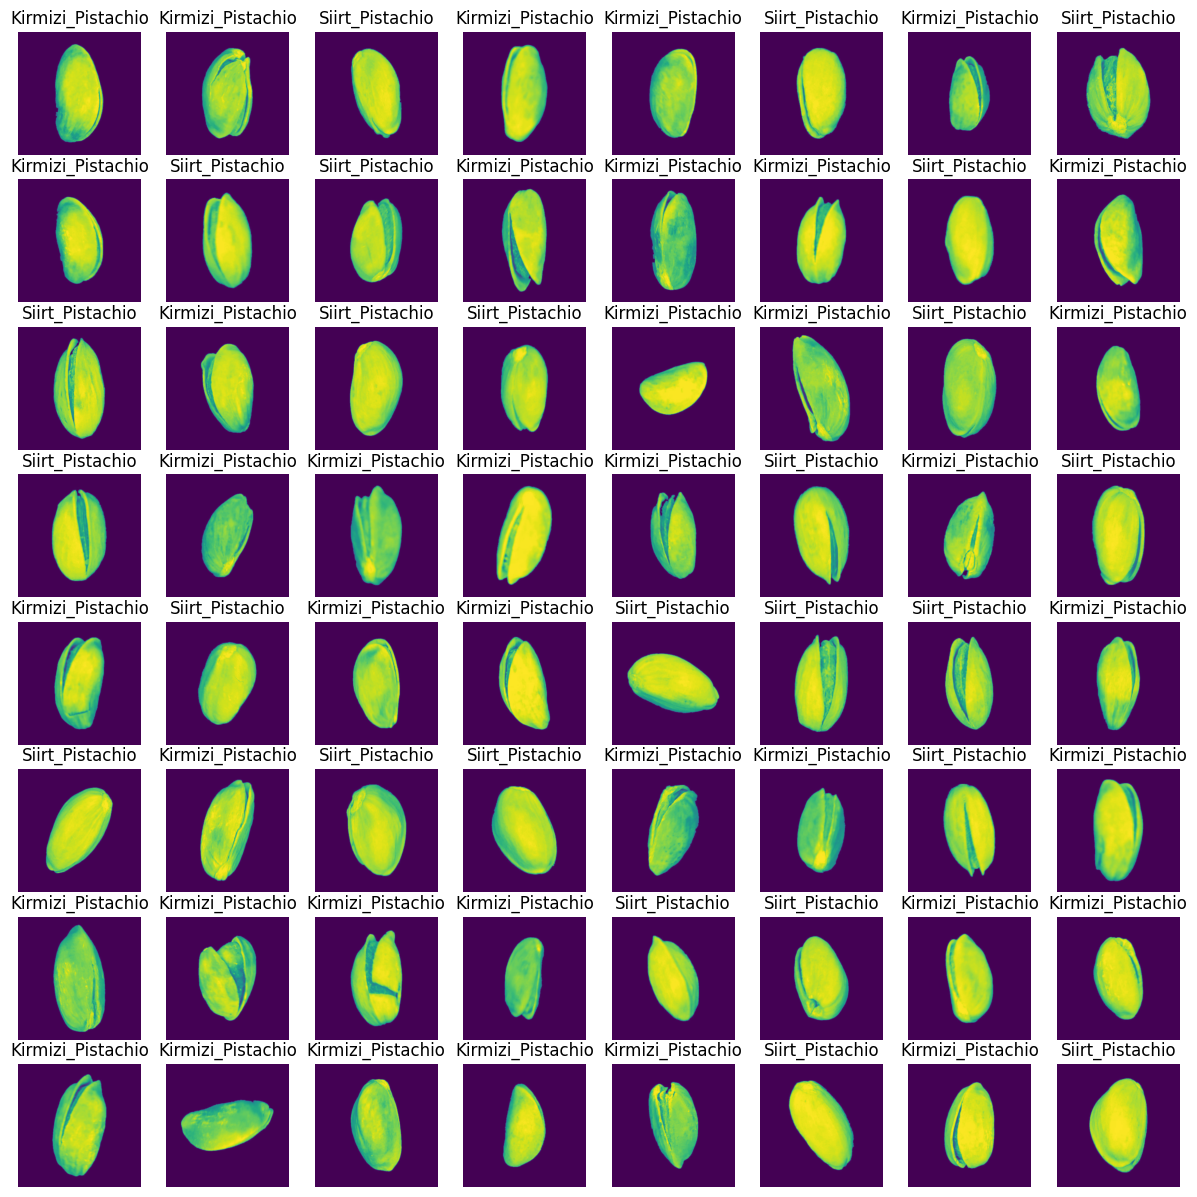

In [4]:
images, labels = next(iter(dataloader))

# Define Class Names
class_names = ["Kirmizi_Pistachio", "Siirt_Pistachio"]

# Plot the Images
plt.figure(figsize=(15, 15))

# Visualize 25 images (5x5 grid)
for i in range(64):
    plt.subplot(8, 8, i+1)
    img = images[i].permute(1, 2, 0)  # Change tensor shape from (C, H, W) -> (H, W, C)

    # Reverse normalization (optional)
    img = img * 0.125 + 0.5  # Because you normalized with mean=0.5 and std=0.125

    # Plot the image
    plt.imshow(img.numpy())
    plt.title(f"{class_names[labels[i].item()]}")
    plt.axis("off")

plt.show()

In [5]:
# Build a Simple CNN Model
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)  # (B, 3, 256, 256) -> (B, 32, 256, 256)
        self.pool = nn.MaxPool2d(2, 2)                                      # (B, 32, 128, 128)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # (B, 64, 128, 128)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1) # (B, 128, 64, 64)

        self.fc1 = nn.Linear(128 * 32 * 32, 256)  # Flatten
        self.fc2 = nn.Linear(256, 3)              # 3 classes: cat, dog, snake

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [6]:
# 2. Set Device, Model, Loss, Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()  # Because 3 classes
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
device

device(type='cuda')

In [8]:
# 3. Train the Model
def train_model(model, dataloader, criterion, optimizer, device, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")
    print("\nTraining Complete!")

# Train for 5 epochs
train_model(model, dataloader, criterion, optimizer, device, epochs=5)

# Save the trained model
torch.save(model.state_dict(), "cnn_classifier.pth")

Epoch 1/5 | Loss: 1.6130 | Accuracy: 71.69%
Epoch 2/5 | Loss: 0.3859 | Accuracy: 82.54%
Epoch 3/5 | Loss: 0.3309 | Accuracy: 85.24%
Epoch 4/5 | Loss: 0.2729 | Accuracy: 87.76%
Epoch 5/5 | Loss: 0.2459 | Accuracy: 89.80%

Training Complete!


In [9]:
# 4. Testing the Model
def test_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"\n🎯 Test Accuracy: {accuracy:.2f}%")

# Testing (on same dataloader because no separate train/test split was mentioned)
test_model(model, dataloader, device)


🎯 Test Accuracy: 92.36%


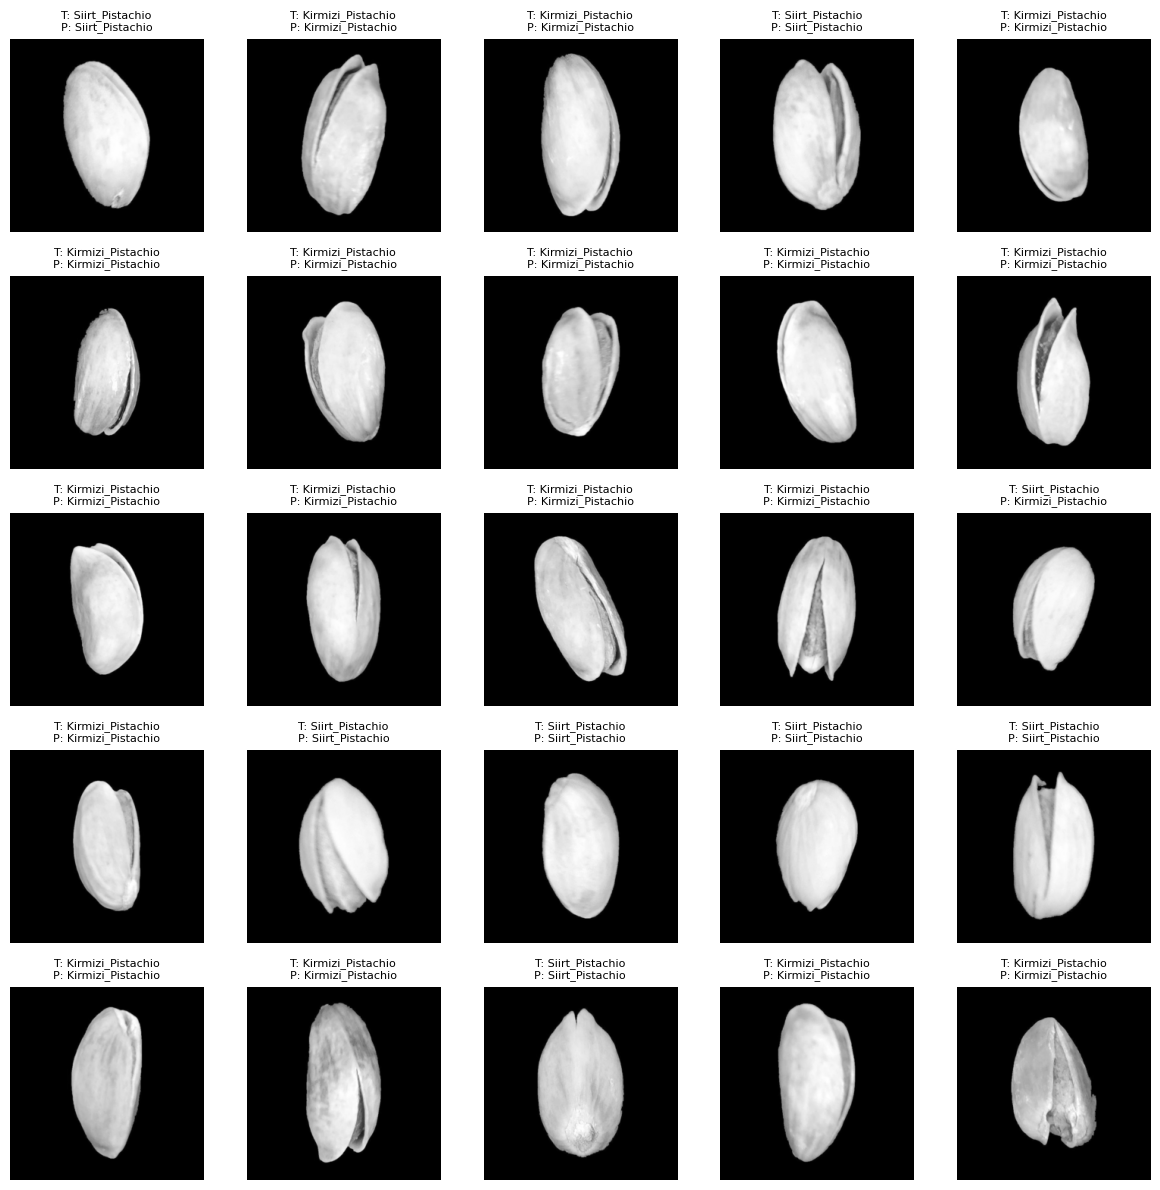

In [11]:
# 5. Predict some samples
model.eval()

# Load one batch
images, labels = next(iter(dataloader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(12, 12))
for idx in range(25):
    plt.subplot(5, 5, idx+1)
    img = images[idx].cpu().permute(1, 2, 0)
    img = img * 0.125 + 0.5  # De-normalize
    plt.imshow(img.squeeze(), cmap='gray')
    true_label = class_names[labels[idx].item()]
    pred_label = class_names[preds[idx].item()]
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()